**Brugada Dataset Exploration**

In [40]:
# CELL 1: Install dependencies
!pip install wfdb pandas numpy matplotlib seaborn scipy

import wfdb
import numpy as np
import pandas as pdS
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, zipfile

In [ ]:
# CELL 2: Unzip dataset in Colab

ZIP_PATH    = "/content/brugada-huca-12-lead-ecg-recordings-for-the-study-of-brugada-syndrome-1.0.0.zip"
EXTRACT_DIR = "/content/"

with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

DATASET_PATH = "/content/brugada-huca-12-lead-ecg-recordings-for-the-study-of-brugada-syndrome-1.0.0"
FILES_PATH   = os.path.join(DATASET_PATH, "files")

In [ ]:
# CELL 3: Load metadata.csv
meta      = pd.read_csv(os.path.join(DATASET_PATH, "metadata.csv"))
meta_dict = pd.read_csv(os.path.join(DATASET_PATH, "metadata_dictionary.csv"))

print("Data Dictionary:")
print(meta_dict.to_string(index=False))
print(f"\n Shape: {meta.shape}")
print("\n First 5 rows:")
print(meta.head())
print(f"\n Unique values in 'brugada' column: {sorted(meta['brugada'].unique())}")
# Expected: [0, 1, 2]
# 0 = Normal, 1 = Confirmed Brugada, 2 = Atypical

Data Dictionary:
     Variable                                       Description
   patient_id                     An identifier for the subject
    diagnosis                      The diagnosis of the subject
 sudden_death Whether the subject has had a sudden death or not
basal_pattern   Whether the baseline ECG is pathological or not
      brugada                      The diagnosis of the subject

 Shape: (363, 4)

 First 5 rows:
   patient_id  basal_pattern  sudden_death  brugada
0      188981              1             0        1
1      251972              0             0        0
2      265715              0             0        0
3      267628              0             0        0
4      267630              0             0        1

 Unique values in 'brugada' column: [np.int64(0), np.int64(1), np.int64(2)]


In [ ]:
# CELL 4: Label distribution
label_map = {0: "Normal", 1: "Brugada", 2: "Atypical"}
meta["label_name"] = meta["brugada"].map(label_map)

print("\n Label distribution:")
dist = meta["brugada"].value_counts().sort_index()
for val, cnt in dist.items():
    print(f"  {val} ({label_map[val]:<10}): {cnt:>4} patients  ({cnt/len(meta)*100:.1f}%)")

# Class imbalance check
n_brugada = (meta["brugada"] == 1).sum()
n_normal  = (meta["brugada"] == 0).sum()
print(f"\n  Brugada:Normal ratio = 1:{n_normal/n_brugada:.1f}")


 Label distribution:
  0 (Normal    ):  287 patients  (79.1%)
  1 (Brugada   ):   69 patients  (19.0%)
  2 (Atypical  ):    7 patients  (1.9%)

  Brugada:Normal ratio = 1:4.2


In [ ]:
# CELL 5: Exploration of other clinical columns
print("\n Cross-tabulation: Brugada × Sudden Death")
print(pd.crosstab(meta["label_name"], meta["sudden_death"],
                  margins=True, margins_name="Total"))

print("\n Cross-tabulation: Brugada × Basal Pattern")
print(pd.crosstab(meta["label_name"], meta["basal_pattern"],
                  margins=True, margins_name="Total"))


 Cross-tabulation: Brugada × Sudden Death
sudden_death    0   1  Total
label_name                  
Atypical        6   1      7
Brugada        65   4     69
Normal        281   6    287
Total         352  11    363

 Cross-tabulation: Brugada × Basal Pattern
basal_pattern    0   1  Total
label_name                   
Atypical         3   4      7
Brugada         50  19     69
Normal         264  23    287
Total          317  46    363


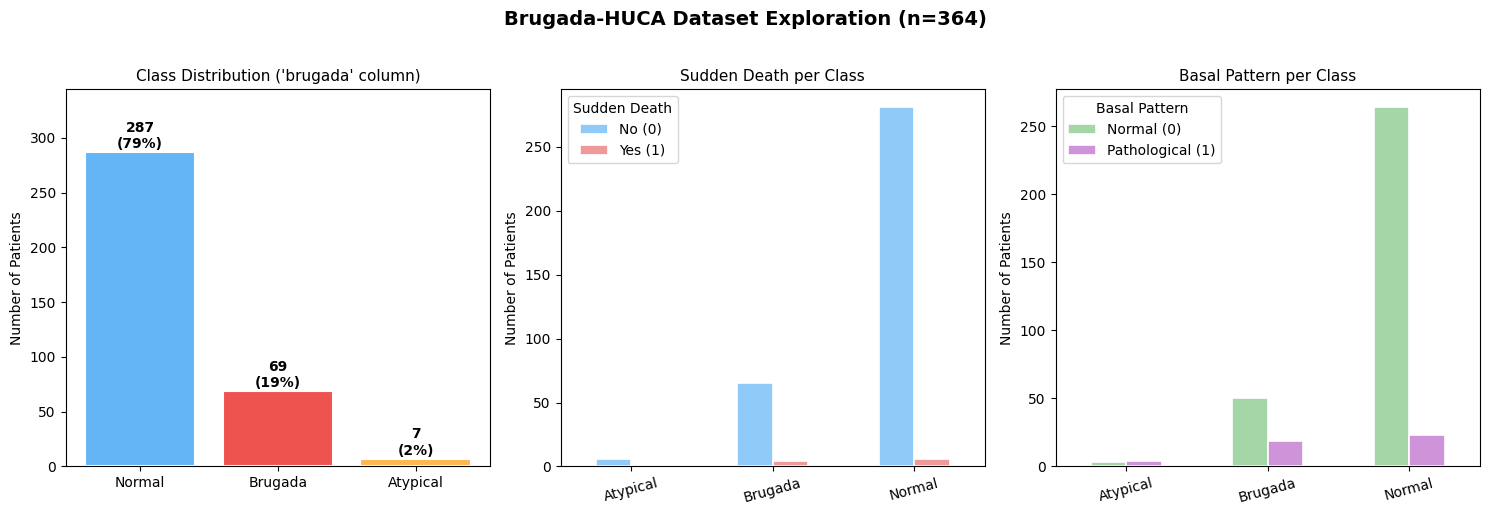

Saved: 01_distribusi_label.png


In [ ]:
# CELL 6: Label distribution visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Brugada-HUCA Dataset Exploration (n=364)",
             fontsize=14, fontweight="bold", y=1.02)

palette = {"Normal": "#64B5F6", "Brugada": "#EF5350", "Atypical": "#FFB74D"}

# (1) Main class distribution
counts = meta["label_name"].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=[palette.get(k, "#ccc") for k in counts.index],
                   edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val}\n({val/len(meta)*100:.0f}%)",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_title("Class Distribution ('brugada' column)", fontsize=11)
axes[0].set_ylabel("Number of Patients")
axes[0].set_ylim(0, counts.max() * 1.2)

# (2) Sudden death per class
ct = pd.crosstab(meta["label_name"], meta["sudden_death"])
ct.plot(kind="bar", ax=axes[1], color=["#90CAF9", "#EF9A9A"],
        edgecolor="white", linewidth=1.2)
axes[1].set_title("Sudden Death per Class", fontsize=11)
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of Patients")
axes[1].legend(["No (0)", "Yes (1)"], title="Sudden Death")
axes[1].tick_params(axis='x', rotation=15)

# (3) Basal pattern per class
ct2 = pd.crosstab(meta["label_name"], meta["basal_pattern"])
ct2.plot(kind="bar", ax=axes[2], color=["#A5D6A7", "#CE93D8"],
         edgecolor="white", linewidth=1.2)
axes[2].set_title("Basal Pattern per Class", fontsize=11)
axes[2].set_xlabel("")
axes[2].set_ylabel("Number of Patients")
axes[2].legend(["Normal (0)", "Pathological (1)"], title="Basal Pattern")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("01_distribusi_label.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 01_distribusi_label.png")

In [ ]:
# CELL 7: Load & verify one WFDB record
with open(os.path.join(DATASET_PATH, "RECORDS")) as f:
    record_names = [l.strip() for l in f if l.strip()]

print(f"\n Total RECORDS: {len(record_names)}")

# Load the first record as a sanity check
sample_rec_name = record_names[0]
sample_rec_path = os.path.join(DATASET_PATH, sample_rec_name)
rec = wfdb.rdrecord(sample_rec_path)

print(f"\n Record successfully loaded: {rec.record_name}")
print(f"   Leads    : {rec.sig_name}")
print(f"   Fs       : {rec.fs} Hz")
print(f"   Duration : {rec.sig_len / rec.fs:.0f} seconds")
print(f"   Shape    : {rec.p_signal.shape}  → ({rec.sig_len} samples × {rec.n_sig} leads)")
print(f"   Unit     : {rec.units}")


 Total RECORDS: 364

 Record successfully loaded: 188981
   Leads    : ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
   Fs       : 100 Hz
   Duration : 12 seconds
   Shape    : (1200, 12)  → (1200 samples × 12 leads)
   Unit     : ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV']


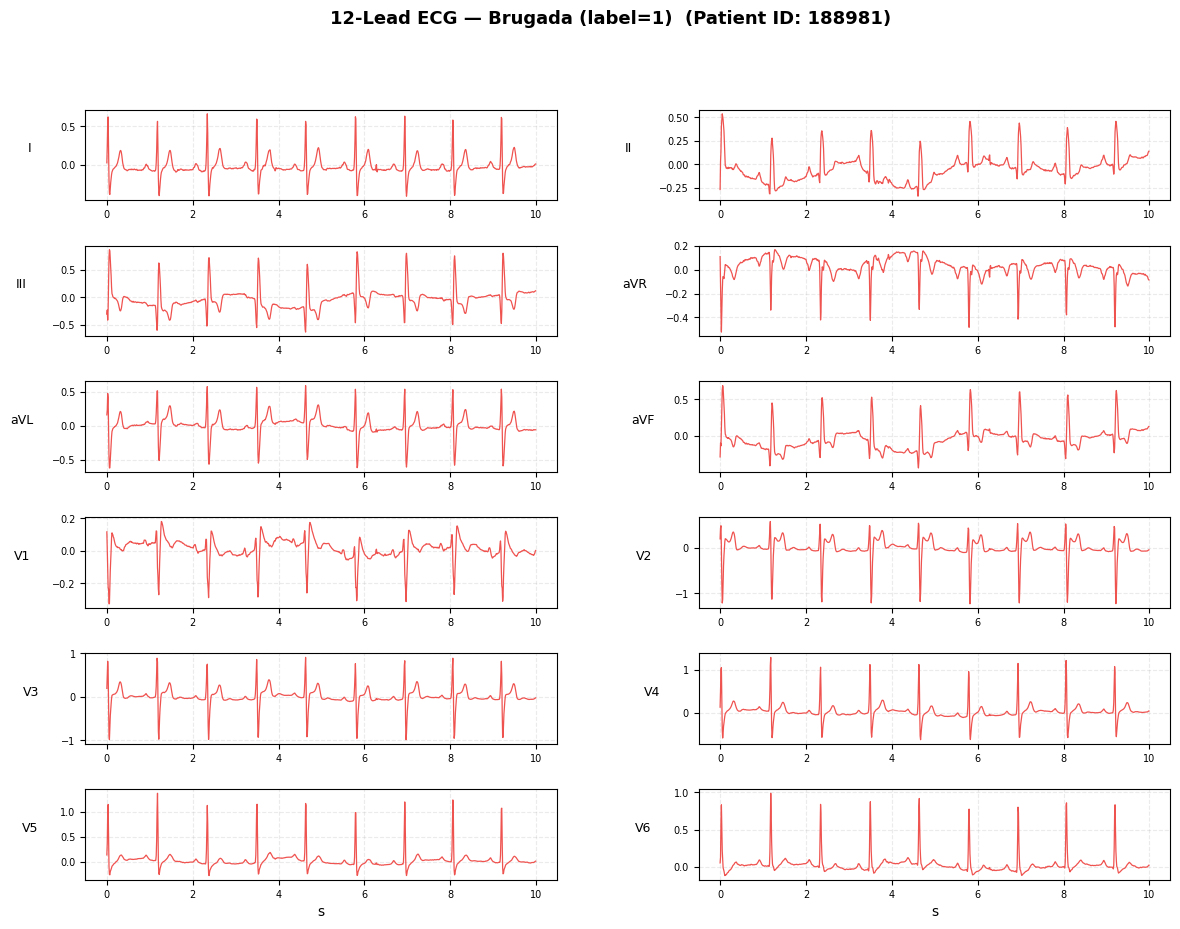

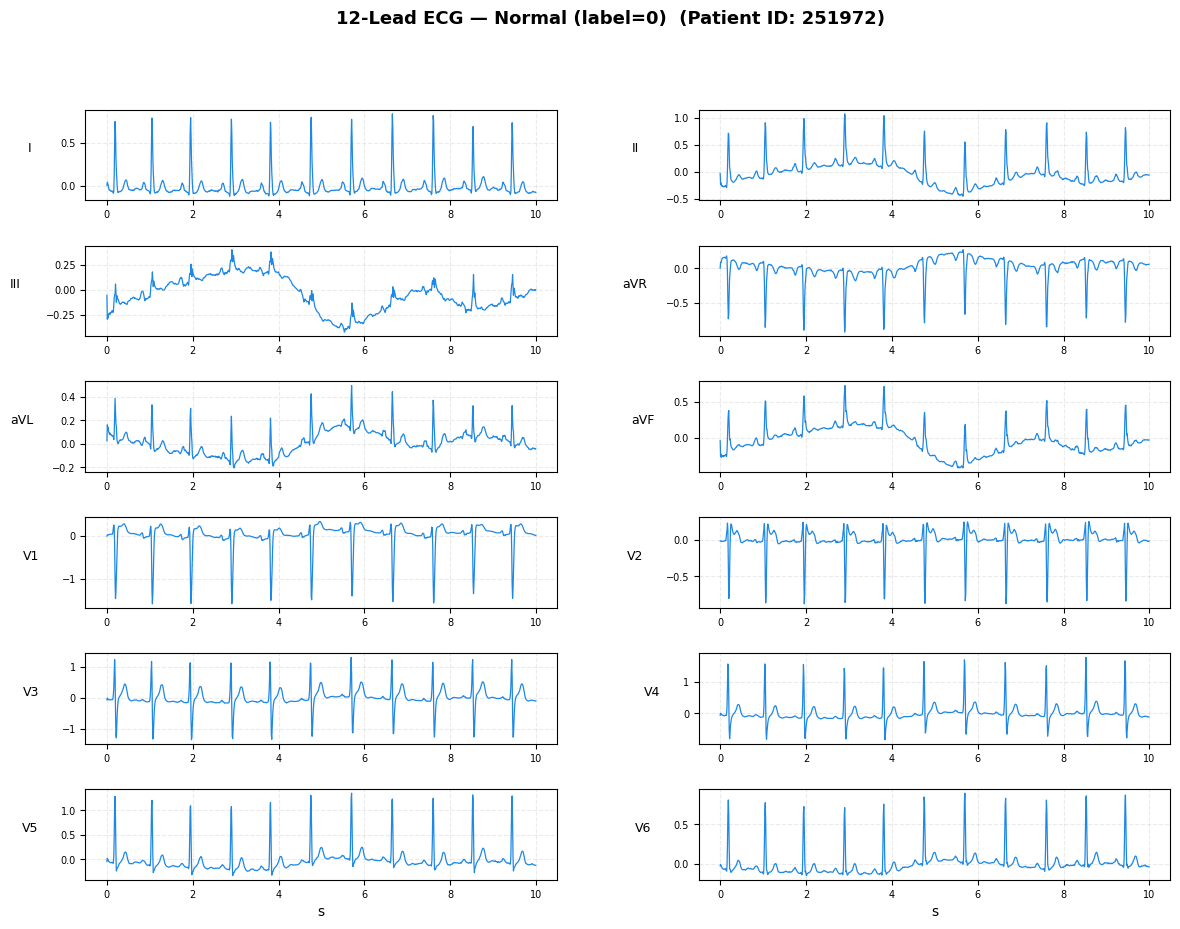

ECG plots saved: 02_ecg_brugada.png & 03_ecg_normal.png


In [ ]:
# CELL 8: Plot 12-lead ECG — Brugada vs Normal
def plot_ecg_12lead(patient_id, label_name, dataset_path, color, duration_s=10):
    """Plot 12-lead ECG for a single patient."""
    rec_path = os.path.join(dataset_path, "files", str(patient_id), str(patient_id))
    rec      = wfdb.rdrecord(rec_path)
    fs       = rec.fs
    n_show   = min(int(duration_s * fs), rec.sig_len)
    signal   = rec.p_signal[:n_show, :]
    t        = np.arange(n_show) / fs
    leads    = rec.sig_name

    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(6, 2, figure=fig, hspace=0.5, wspace=0.3)

    for i, lead in enumerate(leads):
        ax = fig.add_subplot(gs[i // 2, i % 2])
        ax.plot(t, signal[:, i], color=color, linewidth=0.9)
        ax.set_ylabel(lead, fontsize=9, rotation=0, labelpad=22)
        ax.set_xlabel("s" if i >= 10 else "")
        ax.grid(True, alpha=0.25, linestyle="--")
        ax.yaxis.set_tick_params(labelsize=7)
        ax.xaxis.set_tick_params(labelsize=7)

    fig.suptitle(
        f"12-Lead ECG — {label_name}  (Patient ID: {patient_id})",
        fontsize=13, fontweight="bold"
    )
    return fig

# Get example patients for Brugada and Normal from metadata
brugada_id = meta[meta["brugada"] == 1]["patient_id"].iloc[0]
normal_id  = meta[meta["brugada"] == 0]["patient_id"].iloc[0]

fig_b = plot_ecg_12lead(brugada_id, "Brugada (label=1)", DATASET_PATH, "#EF5350")
fig_b.savefig("02_ecg_brugada.png", dpi=150, bbox_inches="tight")
plt.show()

fig_n = plot_ecg_12lead(normal_id, "Normal (label=0)", DATASET_PATH, "#1E88E5")
fig_n.savefig("03_ecg_normal.png", dpi=150, bbox_inches="tight")
plt.show()

print("ECG plots saved: 02_ecg_brugada.png & 03_ecg_normal.png")

In [ ]:
# CELL 9: Save metadata & summary

# Binary classification: 0 = Normal, 1 = Brugada (exclude 2)
meta_binary = meta[meta["brugada"].isin([0, 1])].copy()
meta_binary["label"] = meta_binary["brugada"]

print(f"Total   : {len(meta_binary)} patients")
print(f"Brugada : {(meta_binary['label']==1).sum()}")
print(f"Normal  : {(meta_binary['label']==0).sum()}")

meta_binary.to_csv("metadata_binary.csv", index=False)

Total   : 356 patients
Brugada : 69
Normal  : 287


**Brugada preprocessing**

In [ ]:
# CELL 1: Install & import
!pip install tqdm

from scipy.signal import butter, filtfilt, find_peaks
from tqdm import tqdm
import os, warnings
warnings.filterwarnings("ignore")

DATASET_PATH = "/content/brugada-huca-12-lead-ecg-recordings-for-the-study-of-brugada-syndrome-1.0.0"
FILES_PATH   = os.path.join(DATASET_PATH, "files")
FS           = 100
DURATION     = 12
N_SAMPLES    = FS * DURATION

print(f"Setup:")
print(f"   Fs       = {FS} Hz")
print(f"   Duration = {DURATION} s")
print(f"   N samples = {N_SAMPLES}")

Setup:
   Fs       = 100 Hz
   Duration = 12 s
   N samples = 1200


In [ ]:
# CELL 2: Load binary metadata
meta = pd.read_csv("metadata_binary.csv")   # output from Step 1
print(f"\n  Binary dataset: {len(meta)} patients")
print(f"   Brugada: {(meta['label']==1).sum()}")
print(f"   Normal : {(meta['label']==0).sum()}")


  Binary dataset: 356 patients
   Brugada: 69
   Normal : 287


In [ ]:
# CELL 3: Bandpass filter function
def bandpass_filter(signal, fs=100, lowcut=0.5, highcut=40.0, order=4):
    nyq    = 0.5 * fs
    low    = lowcut  / nyq
    high   = highcut / nyq
    b, a   = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal, axis=0)

def normalize_signal(signal):
    mean = signal.mean(axis=0)
    std  = signal.std(axis=0)
    std[std == 0] = 1
    return (signal - mean) / std

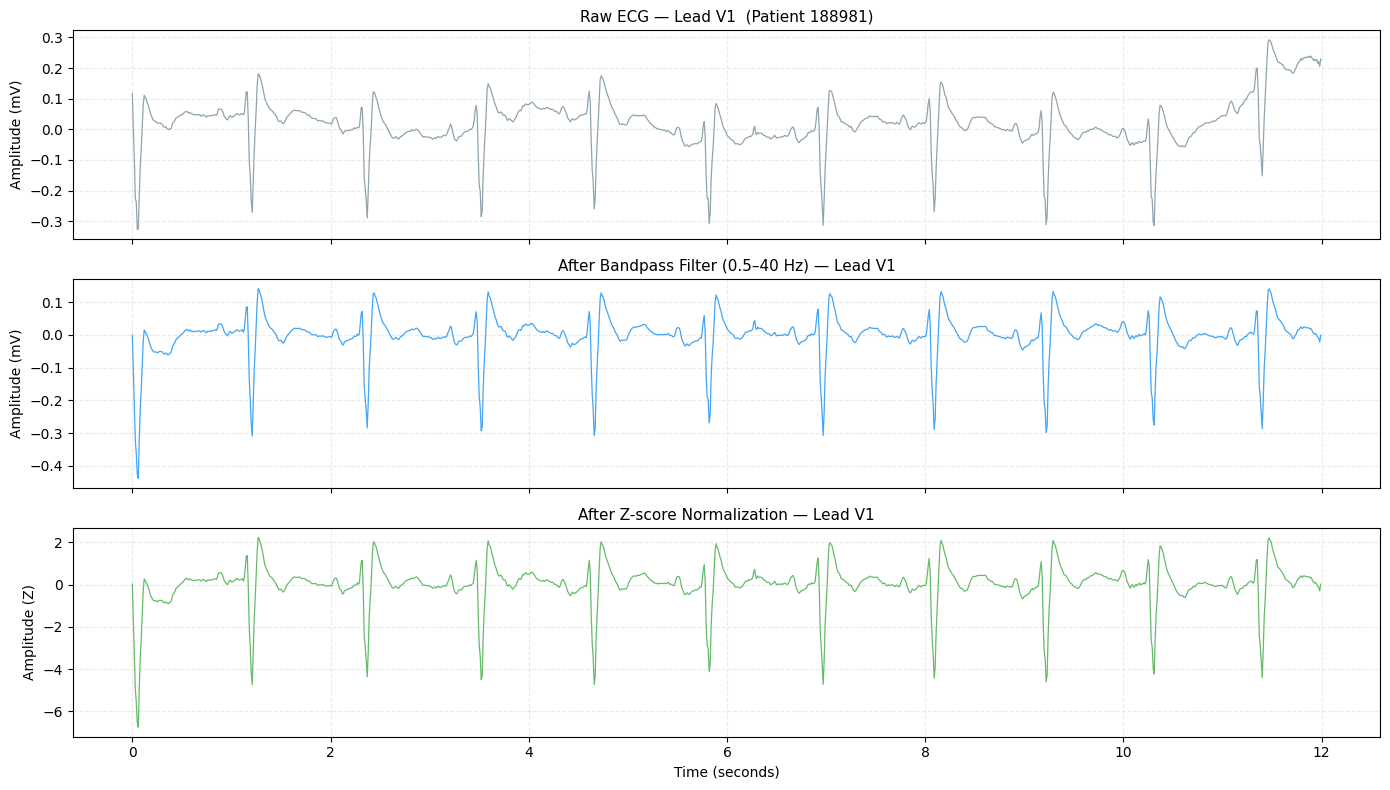

Saved: 04_preprocessing_demo.png


In [ ]:
# CELL 4: Preprocessing demo on 1 record
sample_id  = meta["patient_id"].iloc[0]
rec_path   = os.path.join(FILES_PATH, str(sample_id), str(sample_id))
rec        = wfdb.rdrecord(rec_path)
raw_signal = rec.p_signal

filtered   = bandpass_filter(raw_signal, fs=FS)
normalized = normalize_signal(filtered)

# Visualization before vs after filtering
lead_idx  = 6
lead_name = rec.sig_name[lead_idx]
t         = np.arange(N_SAMPLES) / FS

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(t, raw_signal[:, lead_idx], color="#90A4AE", linewidth=0.9)
axes[0].set_title(f"Raw ECG — Lead {lead_name}  (Patient {sample_id})", fontsize=11)
axes[0].set_ylabel("Amplitude (mV)")

axes[1].plot(t, filtered[:, lead_idx], color="#42A5F5", linewidth=0.9)
axes[1].set_title(f"After Bandpass Filter (0.5–40 Hz) — Lead {lead_name}", fontsize=11)
axes[1].set_ylabel("Amplitude (mV)")

axes[2].plot(t, normalized[:, lead_idx], color="#66BB6A", linewidth=0.9)
axes[2].set_title(f"After Z-score Normalization — Lead {lead_name}", fontsize=11)
axes[2].set_ylabel("Amplitude (Z)")
axes[2].set_xlabel("Time (seconds)")

for ax in axes:
    ax.grid(True, alpha=0.25, linestyle="--")

plt.tight_layout()
plt.savefig("04_preprocessing_demo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 04_preprocessing_demo.png")

In [ ]:
# CELL 5: R-peak detection & feature extraction functions
def detect_r_peaks(signal_lead, fs=100):
    height_thresh = 0.6 * np.max(signal_lead)
    min_distance  = int(0.4 * fs)   # minimum 400 ms between beats (max 150 bpm)
    peaks, _      = find_peaks(signal_lead, height=height_thresh,
                                distance=min_distance)
    return peaks

def extract_features_one_record(patient_id, dataset_path, fs=100):
    rec_path = os.path.join(dataset_path, "files",
                            str(patient_id), str(patient_id))
    try:
        rec    = wfdb.rdrecord(rec_path)
        signal = rec.p_signal
    except Exception as e:
        return None

    # Preprocessing
    signal = bandpass_filter(signal, fs=fs)
    signal = normalize_signal(signal)

    features = {"patient_id": patient_id}
    leads    = rec.sig_name   # ['I','II','III','aVR','aVL','aVF','V1'...'V6']

    # A. Statistical features per lead
    for i, lead in enumerate(leads):
        sig = signal[:, i]
        features[f"{lead}_mean"] = np.mean(sig)
        features[f"{lead}_std"]  = np.std(sig)
        features[f"{lead}_max"]  = np.max(sig)
        features[f"{lead}_min"]  = np.min(sig)

    # B. Temporal features from R-peaks (Lead II = index 1)
    lead_II  = signal[:, 1]
    r_peaks  = detect_r_peaks(lead_II, fs=fs)
    n_beats  = len(r_peaks)

    if n_beats >= 2:
        rr_intervals = np.diff(r_peaks) / fs * 1000   # ms
        features["hr_bpm"]      = 60 / (np.mean(rr_intervals) / 1000)
        features["rr_mean_ms"]  = np.mean(rr_intervals)
        features["rr_std_ms"]   = np.std(rr_intervals)
        rr_diff = np.diff(rr_intervals)
        features["rmssd"]       = np.sqrt(np.mean(rr_diff ** 2)) if len(rr_diff) > 0 else 0
        features["n_beats"]     = n_beats
    else:
        # Fallback if R-peak detection fails
        features["hr_bpm"]     = 0
        features["rr_mean_ms"] = 0
        features["rr_std_ms"]  = 0
        features["rmssd"]      = 0
        features["n_beats"]    = n_beats

    # C. Critical morphology features for Brugada (V1, V2, V3)
    # Lead indices: V1=6, V2=7, V3=8
    for v_idx, v_name in [(6, "V1"), (7, "V2"), (8, "V3")]:
        v_sig = signal[:, v_idx]

        # ST segment: take 40–80 ms after R-peak (= 4–8 samples at 100 Hz)
        st_values = []
        if n_beats >= 1:
            for rp in r_peaks:
                st_start = rp + 4
                st_end   = rp + 8
                if st_end < len(v_sig):
                    st_values.append(np.mean(v_sig[st_start:st_end]))
        features[f"st_mean_{v_name}"] = np.mean(st_values) if st_values else 0

        # T-wave: 80–160 ms after R-peak (= 8–16 samples)
        t_values = []
        if n_beats >= 1:
            for rp in r_peaks:
                t_start = rp + 8
                t_end   = rp + 16
                if t_end < len(v_sig):
                    t_values.append(np.mean(v_sig[t_start:t_end]))
        t_mean = np.mean(t_values) if t_values else 0
        features[f"t_mean_{v_name}"]      = t_mean
        features[f"t_inverted_{v_name}"]  = int(t_mean < -0.1)   # binary flag

        # QRS width proxy: area around R-peak (±5 samples)
        qrs_widths = []
        if n_beats >= 1:
            for rp in r_peaks:
                window = v_sig[max(0, rp-5): min(len(v_sig), rp+5)]
                above  = np.sum(np.abs(window) > 0.5)
                qrs_widths.append(above)
        features[f"qrs_width_{v_name}"] = np.mean(qrs_widths) if qrs_widths else 0

    return features

In [ ]:
# CELL 6: Feature extraction for all records
all_features = []
failed       = []

for _, row in tqdm(meta.iterrows(), total=len(meta), desc="Feature extraction"):
    feat = extract_features_one_record(row["patient_id"], DATASET_PATH, fs=FS)
    if feat is not None:
        feat["label"]         = row["label"]
        feat["sudden_death"]  = row["sudden_death"]
        feat["basal_pattern"] = row["basal_pattern"]
        all_features.append(feat)
    else:
        failed.append(row["patient_id"])

df_features = pd.DataFrame(all_features)
print(f"\n Success: {len(df_features)} records")
print(f" Failed : {len(failed)} records  {failed if failed else ''}")
print(f" Feature shape: {df_features.shape}  → ({len(df_features)} samples × {df_features.shape[1]-3} features + 3 info columns)")

Feature extraction: 100%|██████████| 356/356 [00:09<00:00, 39.06it/s]


 Success: 356 records
 Failed : 0 records  
 Feature shape: (356, 69)  → (356 samples × 66 features + 3 info columns)


In [ ]:
# CELL 7: Check & handle missing values
print("\n Missing values:")
missing = df_features.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) == 0:
    print("   No missing values ")
else:
    print(missing_cols)
    # Fill with column median
    feat_cols = [c for c in df_features.columns
                 if c not in ["patient_id", "label", "sudden_death", "basal_pattern"]]
    df_features[feat_cols] = df_features[feat_cols].fillna(
        df_features[feat_cols].median())
    print("   Filled with column median ")


 Missing values:
   No missing values 


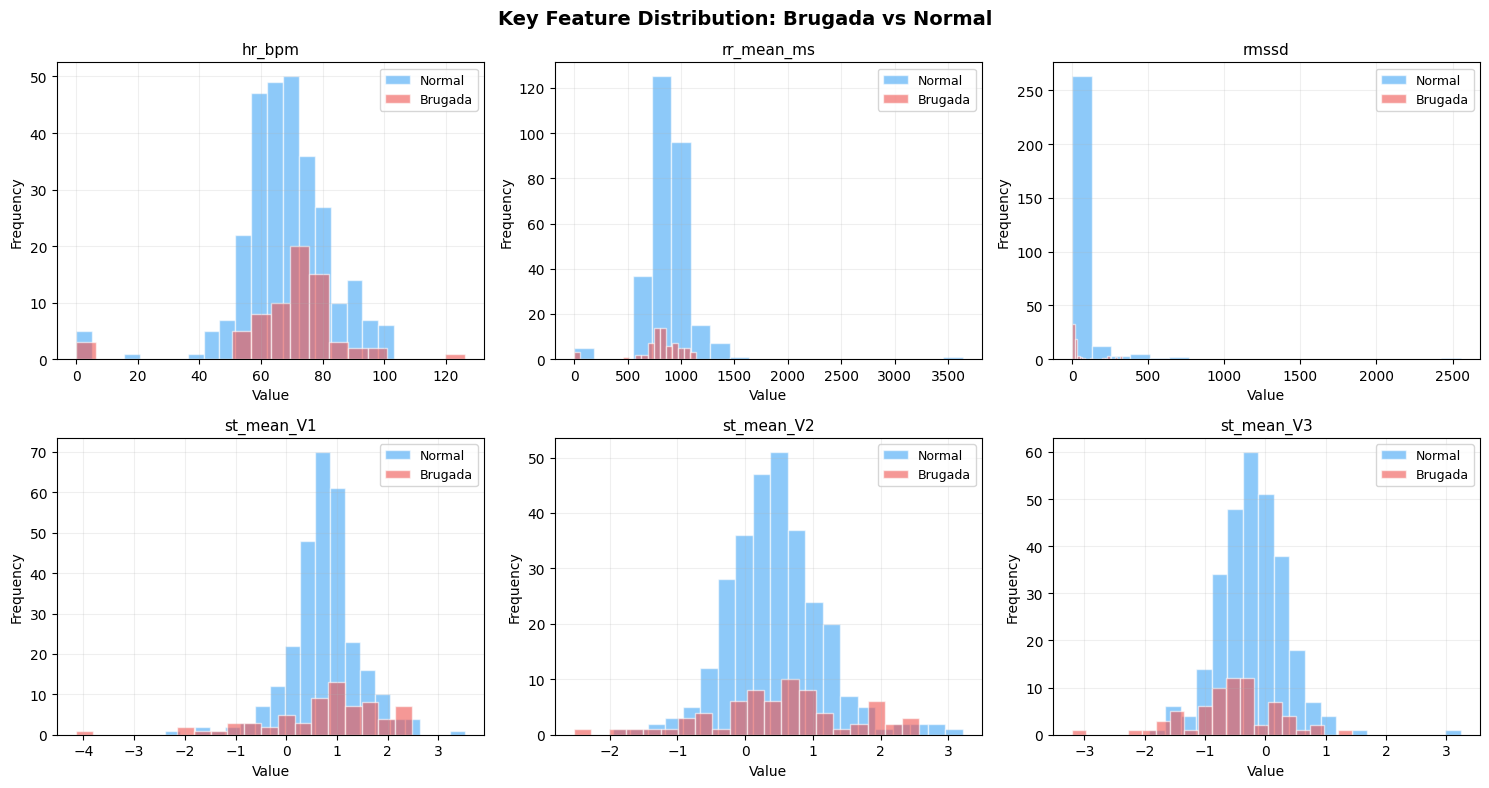

In [ ]:
# CELL 8: Visualization of key feature distributions
key_features = ["hr_bpm", "rr_mean_ms", "rmssd",
                "st_mean_V1", "st_mean_V2", "st_mean_V3"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Key Feature Distribution: Brugada vs Normal",
             fontsize=14, fontweight="bold")
axes = axes.flatten()

colors = {0: "#42A5F5", 1: "#EF5350"}
labels = {0: "Normal", 1: "Brugada"}

for ax, feat in zip(axes, key_features):
    for lbl in [0, 1]:
        vals = df_features[df_features["label"] == lbl][feat].dropna()
        ax.hist(vals, bins=20, alpha=0.6, color=colors[lbl],
                label=labels[lbl], edgecolor="white")
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("05_distribusi_fitur.png", dpi=150, bbox_inches="tight")
plt.show()

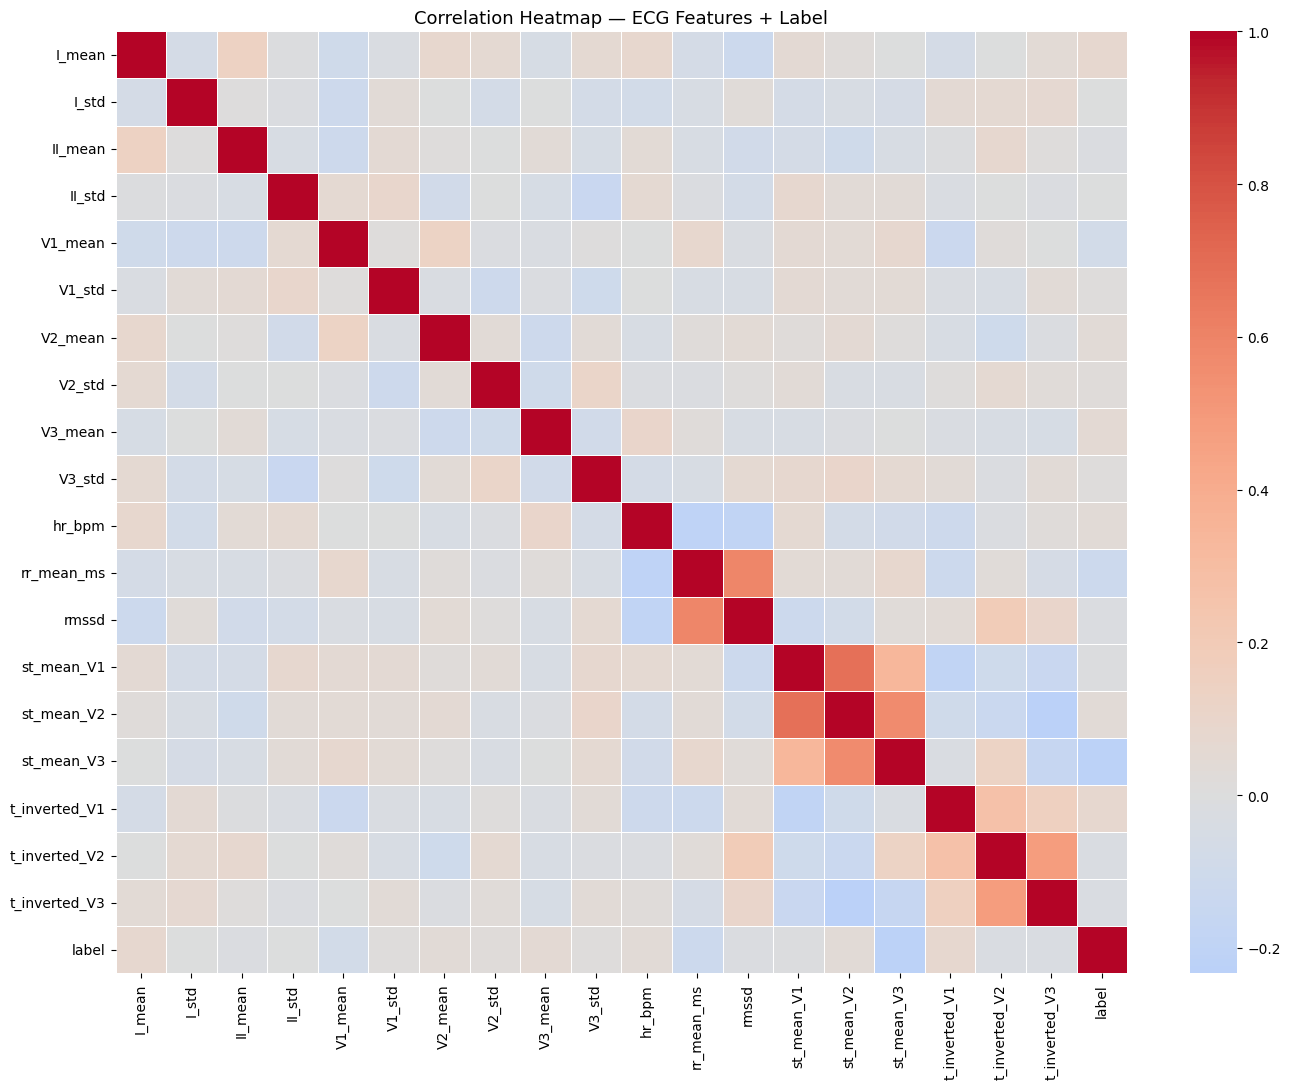

In [ ]:
# CELL 9: Feature correlation heatmap
feat_cols = [c for c in df_features.columns
             if c not in ["patient_id", "label", "sudden_death", "basal_pattern"]]

# Take a subset of the most relevant features for the heatmap (to avoid overcrowding)
key_feat_subset = (
    [f"{l}_{s}" for l in ["I","II","V1","V2","V3"] for s in ["mean","std"]]
    + ["hr_bpm","rr_mean_ms","rmssd"]
    + [f"st_mean_{v}" for v in ["V1","V2","V3"]]
    + [f"t_inverted_{v}" for v in ["V1","V2","V3"]]
)
key_feat_subset = [f for f in key_feat_subset if f in df_features.columns]

corr_df = df_features[key_feat_subset + ["label"]].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_df, annot=False, cmap="coolwarm", center=0,
            linewidths=0.4, square=False)
plt.title("Correlation Heatmap — ECG Features + Label", fontsize=13)
plt.tight_layout()
plt.savefig("06_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# CELL 10: Save features to CSV
output_path = "brugada_features.csv"
df_features.to_csv(output_path, index=False)
print(f"\n Features saved: {output_path}")

# Column summary
print(f"\n Feature columns ({len(feat_cols)} total):")
categories = {
    "Statistical per lead (48)": [c for c in feat_cols if any(c.endswith(s) for s in ["_mean","_std","_max","_min"]) and not c.startswith("st_") and not c.startswith("t_")],
    "Temporal / HRV (5)"     : ["hr_bpm","rr_mean_ms","rr_std_ms","rmssd","n_beats"],
    "ST elevation V1-V3 (3)" : [c for c in feat_cols if c.startswith("st_mean")],
    "T-wave V1-V3 (6)"       : [c for c in feat_cols if c.startswith("t_mean") or c.startswith("t_inv")],
    "QRS width V1-V3 (3)"    : [c for c in feat_cols if c.startswith("qrs_")],
}
for cat, cols in categories.items():
    existing = [c for c in cols if c in feat_cols]
    print(f"   {cat}: {existing[:4]}{'...' if len(existing) > 4 else ''}")

print("\n Dataset summary:")
print(f"  Total samples : {len(df_features)}")
print(f"  Total features: {len(feat_cols)}")
print(f"  Output file   : brugada_features.csv")


 Features saved: brugada_features.csv

 Feature columns (65 total):
   Statistical per lead (48): ['I_mean', 'I_std', 'I_max', 'I_min']...
   Temporal / HRV (5): ['hr_bpm', 'rr_mean_ms', 'rr_std_ms', 'rmssd']...
   ST elevation V1-V3 (3): ['st_mean_V1', 'st_mean_V2', 'st_mean_V3']
   T-wave V1-V3 (6): ['t_mean_V1', 't_inverted_V1', 't_mean_V2', 't_inverted_V2']...
   QRS width V1-V3 (3): ['qrs_width_V1', 'qrs_width_V2', 'qrs_width_V3']

 Dataset summary:
  Total samples : 356
  Total features: 65
  Output file   : brugada_features.csv


**Brugada Training**

In [ ]:
# CELL 1: Install & import
!pip install xgboost shap scikit-learn joblib

import shap
import joblib

from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble           import RandomForestClassifier
from sklearn.preprocessing      import StandardScaler
from sklearn.metrics            import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, accuracy_score,
    average_precision_score, precision_recall_curve
)
from sklearn.pipeline           import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from xgboost                    import XGBClassifier

In [ ]:
# CELL 2: Load & prepare data
df = pd.read_csv("brugada_features.csv")   # output from Step 2

# Feature columns (exclude info columns)
info_cols = ["patient_id", "label", "sudden_death", "basal_pattern"]
feat_cols = [c for c in df.columns if c not in info_cols]

X = df[feat_cols].values
y = df["label"].values   # 0=Normal, 1=Brugada

print(f"Shape X: {X.shape}")
print(f"Label distribution: {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"Number of features: {len(feat_cols)}")

Shape X: (356, 65)
Label distribution: {np.int64(0): np.int64(287), np.int64(1): np.int64(69)}
Number of features: 65


In [ ]:
# CELL 3: Stratified train/val/test split
# Split: 60% train | 20% val | 20% test
# Stratified = Brugada:Normal proportion is preserved in each split

X_temp,  X_test,  y_temp,  y_test  = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
X_train, X_val,   y_train, y_val   = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)
# 0.25 * 0.80 = 0.20 of total → val=20%, train=60%

print(f"\n Split Results:")
print(f"   Train : {len(X_train)} samples | Brugada={y_train.sum()} Normal={len(y_train)-y_train.sum()}")
print(f"   Val   : {len(X_val)}   samples | Brugada={y_val.sum()}  Normal={len(y_val)-y_val.sum()}")
print(f"   Test  : {len(X_test)}  samples | Brugada={y_test.sum()} Normal={len(y_test)-y_test.sum()}")


 Split Results:
   Train : 213 samples | Brugada=41 Normal=172
   Val   : 71   samples | Brugada=14  Normal=57
   Test  : 72  samples | Brugada=14 Normal=58


In [ ]:
# ── CELL 4: Compute class weights (handle imbalance) ──────────
classes      = np.array([0, 1])
class_weights = compute_class_weight("balanced", classes=classes, y=y_train)
cw_dict       = dict(zip(classes, class_weights))
scale_pos_weight = class_weights[1] / class_weights[0]   # for XGBoost

print(f"\n Class weights: {cw_dict}")
print(f" scale_pos_weight (XGBoost): {scale_pos_weight:.2f}")


 Class weights: {np.int64(0): np.float64(0.6191860465116279), np.int64(1): np.float64(2.597560975609756)}
 scale_pos_weight (XGBoost): 4.20


In [49]:
# CELL 5: Model definition
# Scaler for feature normalization before feeding into models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Model A: Random Forest
rf_model = RandomForestClassifier(
    n_estimators    = 300,
    max_depth       = None,
    min_samples_leaf= 2,
    class_weight    = "balanced",
    random_state    = 42,
    n_jobs          = -1
)

# Model B: XGBoost
xgb_model = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 4,
    learning_rate     = 0.03,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = 4.2,   # handle imbalance
    eval_metric       = "auc", # Changed from logloss to auc
    random_state      = 42,
    n_jobs            = -1
)

print("Models defined:")
print("   A. RandomForestClassifier (n=300, class_weight=balanced)")
print(f"   B. XGBClassifier          (n=500, max_depth=4, learning_rate=0.03, scale_pos_weight=4.2, eval_metric=\"auc\")")

Models defined:
   A. RandomForestClassifier (n=300, class_weight=balanced)
   B. XGBClassifier          (n=500, max_depth=4, learning_rate=0.03, scale_pos_weight=4.2, eval_metric="auc")


In [50]:
# CELL 6: Training
# Train Random Forest
rf_model.fit(X_train_sc, y_train)

# Train XGBoost
xgb_model.fit(
    X_train_sc, y_train,
    eval_set   = [(X_val_sc, y_val)],
    verbose    = False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

In [51]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, X_te, y_te,
                   model_name="Model", feat_names=None, threshold=0.3):

    results = {}
    for split_name, Xs, ys in [("Train", X_tr, y_tr),
                                 ("Val",   X_v,  y_v),
                                 ("Test",  X_te, y_te)]:
        y_prob      = model.predict_proba(Xs)[:, 1]
        y_pred      = (y_prob > threshold).astype(int)

        results[split_name] = {
            "accuracy"  : accuracy_score(ys, y_pred),
            "auc_roc"   : roc_auc_score(ys, y_prob),
            "f1"        : f1_score(ys, y_pred, zero_division=0),
            "precision" : precision_score(ys, y_pred, zero_division=0),
            "recall"    : recall_score(ys, y_pred, zero_division=0),
            "auc_pr"    : average_precision_score(ys, y_prob),
        }

    # Print table
    print(f"\n{'='*60}")
    print(f"  {model_name} — Evaluation Results")
    print(f"{'='*60}")
    print(f"  {'Metric':<15} {'Train':>8} {'Val':>8} {'Test':>8}")
    print(f"  {'-'*45}")
    for metric in ["accuracy","auc_roc","f1","precision","recall","auc_pr"]:
        vals = [results[s][metric] for s in ["Train","Val","Test"]]
        flag = " <-" if metric == "auc_roc" else ""
        print(f"  {metric:<15} {vals[0]:>8.4f} {vals[1]:>8.4f} {vals[2]:>8.4f}{flag}")
    print(f"{'='*60}")

    # Confusion matrix (test set)
    y_prob_test = model.predict_proba(X_te)[:, 1]
    y_pred_test = (y_prob_test > threshold).astype(int)
    cm          = confusion_matrix(y_te, y_pred_test)
    print(f"\n  Confusion Matrix (Test set):")
    print(f"  {'':>12} Pred Normal  Pred Brugada")
    print(f"  True Normal  {cm[0,0]:>8}      {cm[0,1]:>8}")
    print(f"  True Brugada {cm[1,0]:>8}      {cm[1,1]:>8}")
    tn,fp,fn,tp = cm.ravel()
    print(f"\n  Sensitivity (Recall) : {tp/(tp+fn):.4f}  ← % Brugada detected")
    print(f"  Specificity          : {tn/(tn+fp):.4f}  ← % Normal detected")

    return results

In [52]:
# CELL 8: Evaluate both models
results_rf  = evaluate_model(rf_model,  X_train_sc, y_train,
                              X_val_sc,  y_val,
                              X_test_sc, y_test,
                              model_name="Random Forest", feat_names=feat_cols, threshold=0.3)

results_xgb = evaluate_model(xgb_model, X_train_sc, y_train,
                              X_val_sc,  y_val,
                              X_test_sc, y_test,
                              model_name="XGBoost", feat_names=feat_cols, threshold=0.3)


  Random Forest — Evaluation Results
  Metric             Train      Val     Test
  ---------------------------------------------
  accuracy          0.9906   0.8169   0.8194
  auc_roc           1.0000   0.8784   0.7845 <-
  f1                0.9762   0.5806   0.5185
  precision         0.9535   0.5294   0.5385
  recall            1.0000   0.6429   0.5000
  auc_pr            1.0000   0.7503   0.5615

  Confusion Matrix (Test set):
               Pred Normal  Pred Brugada
  True Normal        52             6
  True Brugada        7             7

  Sensitivity (Recall) : 0.5000  ← % Brugada detected
  Specificity          : 0.8966  ← % Normal detected

  XGBoost — Evaluation Results
  Metric             Train      Val     Test
  ---------------------------------------------
  accuracy          1.0000   0.8873   0.8056
  auc_roc           1.0000   0.8997   0.7352 <-
  f1                1.0000   0.6923   0.4615
  precision         1.0000   0.7500   0.5000
  recall            1.0000   0.

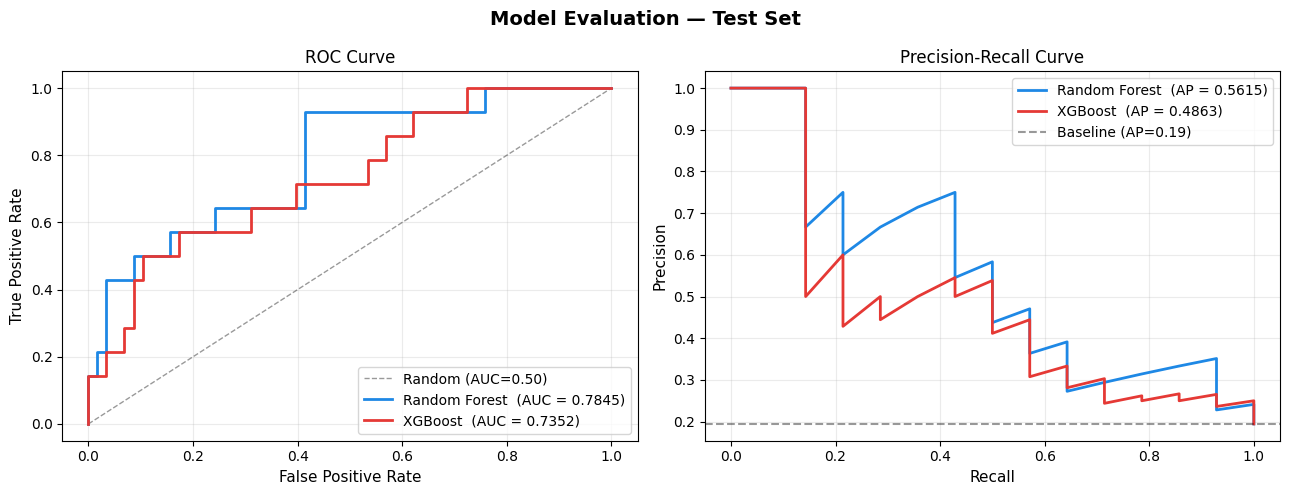

In [53]:
# CELL 9: Plot ROC & PR curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Model Evaluation — Test Set", fontsize=14, fontweight="bold")

models_info = [
    (rf_model,  "Random Forest", "#1E88E5"),
    (xgb_model, "XGBoost",       "#E53935"),
]

# ROC Curve
axes[0].plot([0,1],[0,1], "k--", alpha=0.4, linewidth=1, label="Random (AUC=0.50)")
for model, name, color in models_info:
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{name}  (AUC = {auc:.4f})")
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].set_title("ROC Curve", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.25)

# Precision-Recall Curve
for model, name, color in models_info:
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    auc_pr = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, color=color, linewidth=2,
                 label=f"{name}  (AP = {auc_pr:.4f})")
baseline = y_test.sum() / len(y_test)
axes[1].axhline(baseline, color="k", linestyle="--", alpha=0.4,
                label=f"Baseline (AP={baseline:.2f})")
axes[1].set_xlabel("Recall", fontsize=11)
axes[1].set_ylabel("Precision", fontsize=11)
axes[1].set_title("Precision-Recall Curve", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("07_roc_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [54]:
# CELL 10: Cross-validation (5-fold)
print("\n 5-Fold Stratified Cross-Validation (entire dataset):")
X_all_sc = scaler.fit_transform(X)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model, name in [(rf_model, "Random Forest"), (xgb_model, "XGBoost")]:
    cv_auc = cross_val_score(model, X_all_sc, y, cv=cv,
                             scoring="roc_auc", n_jobs=-1)
    cv_f1  = cross_val_score(model, X_all_sc, y, cv=cv,
                             scoring="f1", n_jobs=-1)
    print(f"\n  {name}:")
    print(f"    AUC-ROC : {cv_auc.mean():.4f} \u00b1 {cv_auc.std():.4f}")
    print(f"    F1      : {cv_f1.mean():.4f}  \u00b1 {cv_f1.std():.4f}")


 5-Fold Stratified Cross-Validation (entire dataset):

  Random Forest:
    AUC-ROC : 0.8427 ± 0.0715
    F1      : 0.5095  ± 0.0976

  XGBoost:
    AUC-ROC : 0.8438 ± 0.0754
    F1      : 0.5942  ± 0.0758



 Computing SHAP values (Random Forest)


<Figure size 1000x800 with 0 Axes>

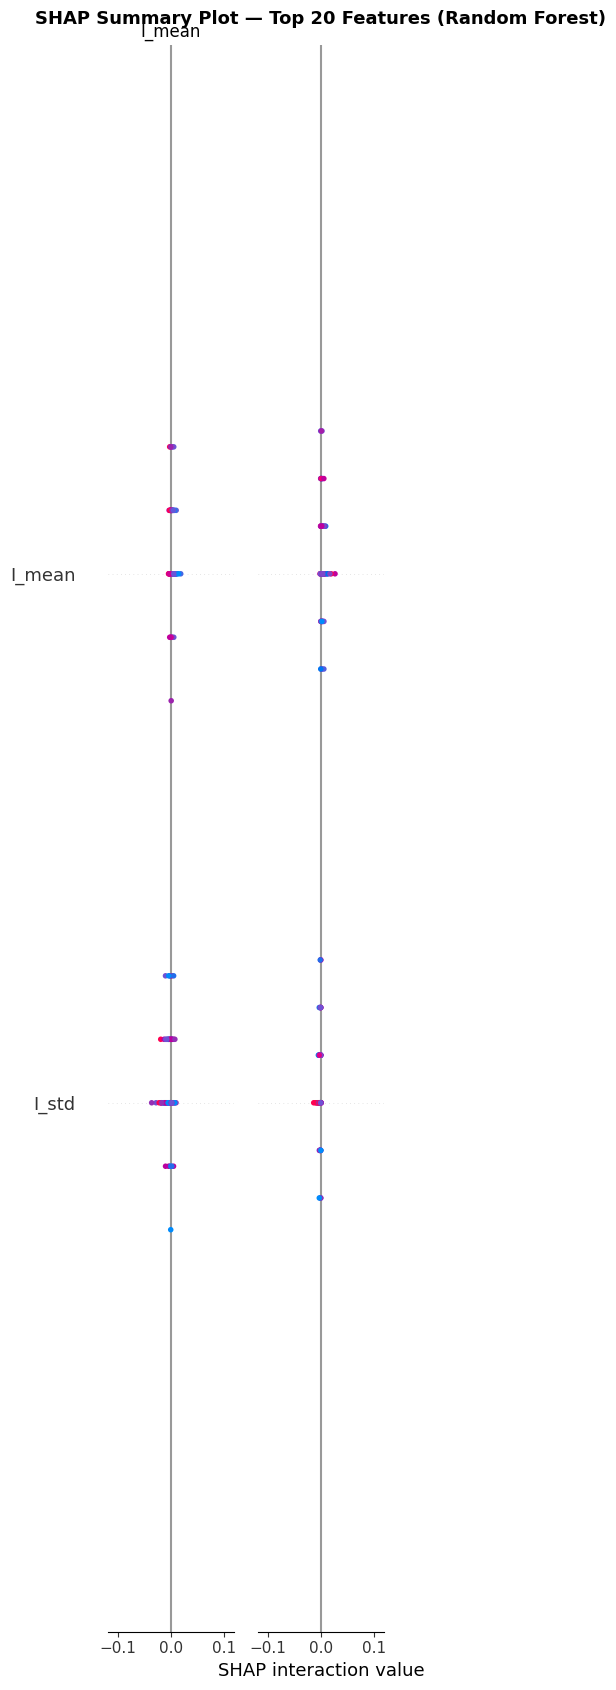

<Figure size 1000x700 with 0 Axes>

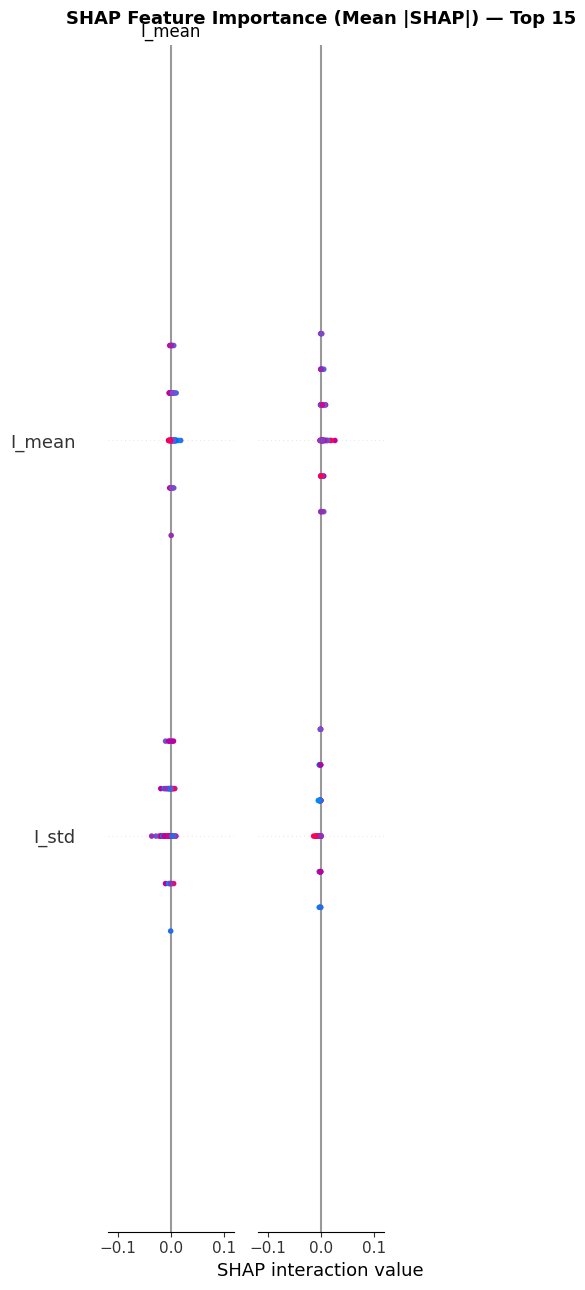

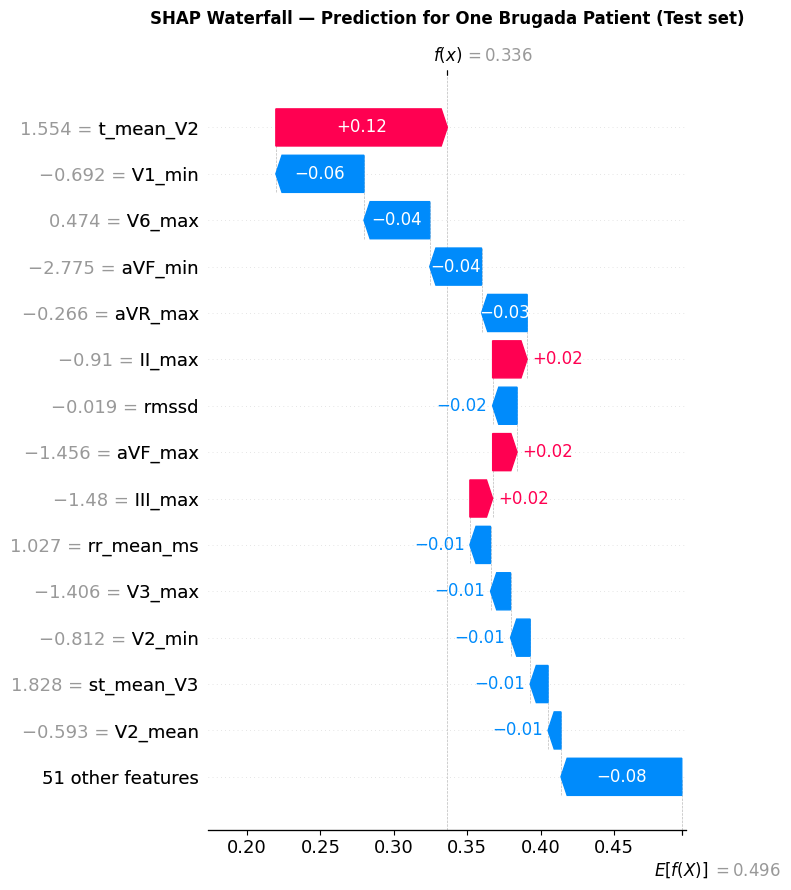

In [57]:
# CELL 11: SHAP — Interpretability
# SHAP = SHapley Additive exPlanations

print("\n Computing SHAP values (Random Forest)")
explainer_rf  = shap.TreeExplainer(rf_model)
shap_values   = explainer_rf.shap_values(X_test_sc)

# shap_values[1] = SHAP values for Brugada class (label=1)
shap_brugada  = shap_values[1] if isinstance(shap_values, list) else shap_values

# (A) SHAP Summary Plot — global feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_brugada, X_test_sc,
    feature_names = feat_cols,
    max_display   = 20,
    show          = False,
    plot_type     = "dot"
)
plt.title("SHAP Summary Plot — Top 20 Features (Random Forest)", fontsize=13,
          fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("08_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# (B) SHAP Bar Plot — mean |SHAP| per feature
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_brugada, X_test_sc,
    feature_names = feat_cols,
    max_display   = 15,
    show          = False,
    plot_type     = "bar"
)
plt.title("SHAP Feature Importance (Mean |SHAP|) — Top 15", fontsize=13,
          fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("09_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# (C) SHAP Waterfall — one Brugada patient (individual explanation)
brugada_test_idx = np.where(y_test == 1)[0]
if len(brugada_test_idx) > 0:
    idx = brugada_test_idx[0]
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values        = shap_brugada[idx][:,1],
            base_values   = explainer_rf.expected_value[1],
            data          = X_test_sc[idx, :],
            feature_names = feat_cols
        ),
        max_display = 15,
        show        = False
    )
    plt.title(f"SHAP Waterfall — Prediction for One Brugada Patient (Test set)",
              fontsize=12, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.savefig("10_shap_waterfall_brugada.png", dpi=150, bbox_inches="tight")
    plt.show()

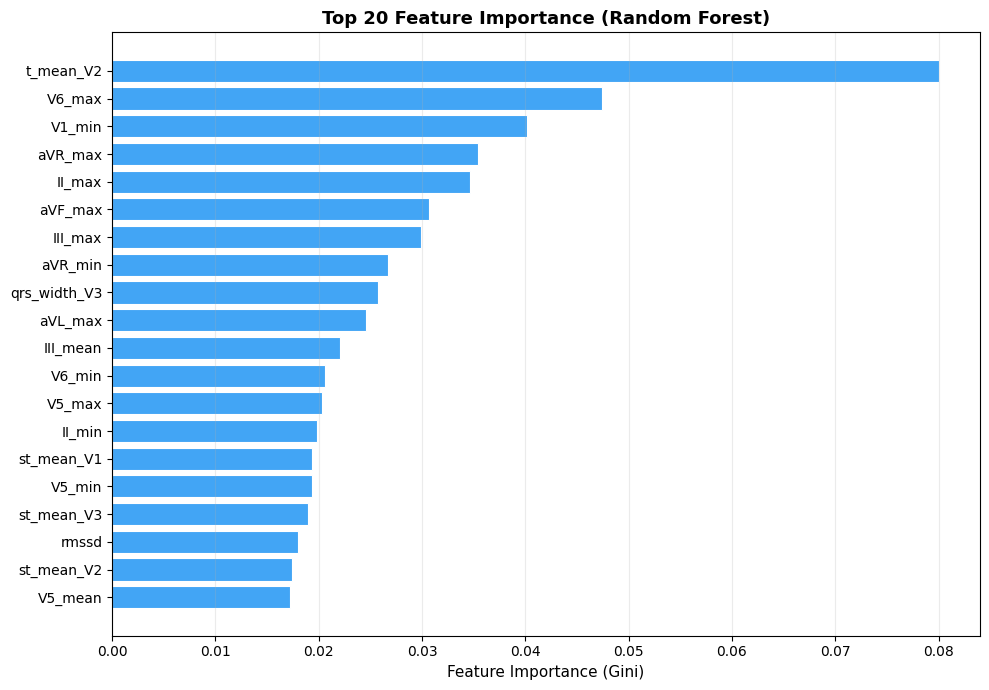


 Top 10 most important features:
   1. t_mean_V2                      0.0800
   2. V6_max                         0.0474
   3. V1_min                         0.0401
   4. aVR_max                        0.0355
   5. II_max                         0.0346
   6. aVF_max                        0.0306
   7. III_max                        0.0299
   8. aVR_min                        0.0267
   9. qrs_width_V3                   0.0258
  10. aVL_max                        0.0246


In [56]:
# CELL 12: Traditional feature importance (backup)
feat_imp = pd.Series(rf_model.feature_importances_, index=feat_cols)
top20    = feat_imp.nlargest(20)

plt.figure(figsize=(10, 7))
bars = plt.barh(top20.index[::-1], top20.values[::-1],
                color="#42A5F5", edgecolor="white", linewidth=0.8)
plt.xlabel("Feature Importance (Gini)", fontsize=11)
plt.title("Top 20 Feature Importance (Random Forest)", fontsize=13,
          fontweight="bold")
plt.grid(True, alpha=0.25, axis="x")
plt.tight_layout()
plt.savefig("11_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n Top 10 most important features:")
for i, (feat, imp) in enumerate(top20.head(10).items(), 1):
    print(f"  {i:>2}. {feat:<30} {imp:.4f}")

In [47]:
# CELL 13: Save models & scaler
joblib.dump(rf_model,  "model_rf.pkl")
joblib.dump(xgb_model, "model_xgb.pkl")
joblib.dump(scaler,    "scaler.pkl")
pd.Series(feat_cols).to_csv("feature_names.csv", index=False, header=False)

print("\n Models saved:")
print("   model_rf.pkl  — Random Forest")
print("   model_xgb.pkl — XGBoost")
print("   scaler.pkl    — StandardScaler")
print("   feature_names.csv")


 Models saved:
   model_rf.pkl  — Random Forest
   model_xgb.pkl — XGBoost
   scaler.pkl    — StandardScaler
   feature_names.csv


In [48]:
# CELL 14: Final summary
print("\n" + "="*60)
print("TRAINING & EVALUATION RESULTS")
print("="*60)
print("  Output files:")
print("   07_roc_pr_curve.png        ← ROC & PR curve")
print("   08_shap_summary.png        ← SHAP dot plot")
print("   09_shap_bar.png            ← SHAP importance bar")
print("   10_shap_waterfall_brugada  ← SHAP individual explanation")
print("   11_feature_importance.png  ← Gini importance")
print("   model_rf.pkl / model_xgb.pkl / scaler.pkl")


TRAINING & EVALUATION RESULTS
  Output files:
   07_roc_pr_curve.png        ← ROC & PR curve
   08_shap_summary.png        ← SHAP dot plot
   09_shap_bar.png            ← SHAP importance bar
   10_shap_waterfall_brugada  ← SHAP individual explanation
   11_feature_importance.png  ← Gini importance
   model_rf.pkl / model_xgb.pkl / scaler.pkl
